# Airfoil CL/CD Optimisation — full pipeline

Maximises **CL / CD** vs the kc135 baseline at fixed flow conditions (Re = 1e6, AoA = 10°), subject to:

- `CL ≥ 0.10`             (positive lift, with margin)
- thickness profile `≤ 0.9 × kc135` at x = 0.2, 0.4, 0.6, 0.8     (10 % thinner everywhere)
- geometric coherence       (`max_camber ≥ c25/c50/c75`, aft-monotone thinning)
- physical bounds           (LE radius > 0, thickness > 0, camber position ∈ [0, 1])

Runs **SLSQP**, **COBYQA**, and **trust-constr**, tracks every function evaluation and the maximum constraint violation at that point, then plots both histories and reconstructs the airfoil shapes.

All heavy lifting is in four helper modules in this folder:

| file                       | what's in it |
|----------------------------|--------------|
| `airfoil_opt_utils.py`     | model loader, kc135 baseline, bounds, scaler, problem builder |
| `tracked_optimisation.py`  | per-evaluation history wrapper + the three solver runners + plot helpers |
| `plot_airfoil.py`          | reconstructs upper/lower surfaces from the 12-feature vector |
| `evaluate_model.py`        | re-does the train/test split and reports R² / MAE / RMSE |

Run all cells top to bottom.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────
import warnings
import numpy as np
import matplotlib.pyplot as plt

from airfoil_opt_utils import (
    build_problem, KC135_GEOM, GEOM_NAMES, COHERENCE_LABELS,
)
from tracked_optimisation import (
    run_slsqp, run_cobyqa, run_trust_constr,
    plot_objective_history, plot_violation_history,
    summary_table, save_results,
)
from plot_airfoil    import plot_airfoils
from evaluate_model  import evaluate

%matplotlib inline
warnings.filterwarnings("ignore", message="delta_grad == 0")  # benign trust-constr chatter
np.set_printoptions(precision=4, suppress=True)
print("modules loaded")

modules loaded


## 0. Surrogate accuracy — R² on the train/test split

Replicates the original preprocessing (drop NaNs, log-transform CD), redoes the same `train_test_split(test_size=0.2, random_state=42)` that produced the saved model, and reports R² / MAE / RMSE for:

- the three trained outputs:  CL, log(CD), CM
- the de-normalised CD (after `exp(log CD)`)
- the **derived CL/CD** — this is what the optimiser actually maximises, so its R² is what you should trust the most

The parity plot is on the test set (n ≈ 569). A well-trained model puts every dot on the red diagonal.

Rows total : 2845   train: 2276   test: 569

════════════════════════════════════════════════════════════════
  R²  (model outputs in trained space)
════════════════════════════════════════════════════════════════
                       CL     log(CD)          CM
  train            0.9907      0.9758      0.9652
  test             0.9941      0.9624      0.9630

════════════════════════════════════════════════════════════════
  R²  (physical CD and derived CL/CD)
════════════════════════════════════════════════════════════════
                       CD       CL/CD
  train            0.9423      0.9773
  test             0.9279      0.9731

════════════════════════════════════════════════════════════════
  Test errors
════════════════════════════════════════════════════════════════
  MAE   :  CL = 0.0347   log CD = 0.0916   CM = 0.0052
  RMSE  :  CL = 0.0551   log CD = 0.1607   CM = 0.0092
  CL/CD :  MAE = 3.820   RMSE = 6.362



Saved → model_parity.png


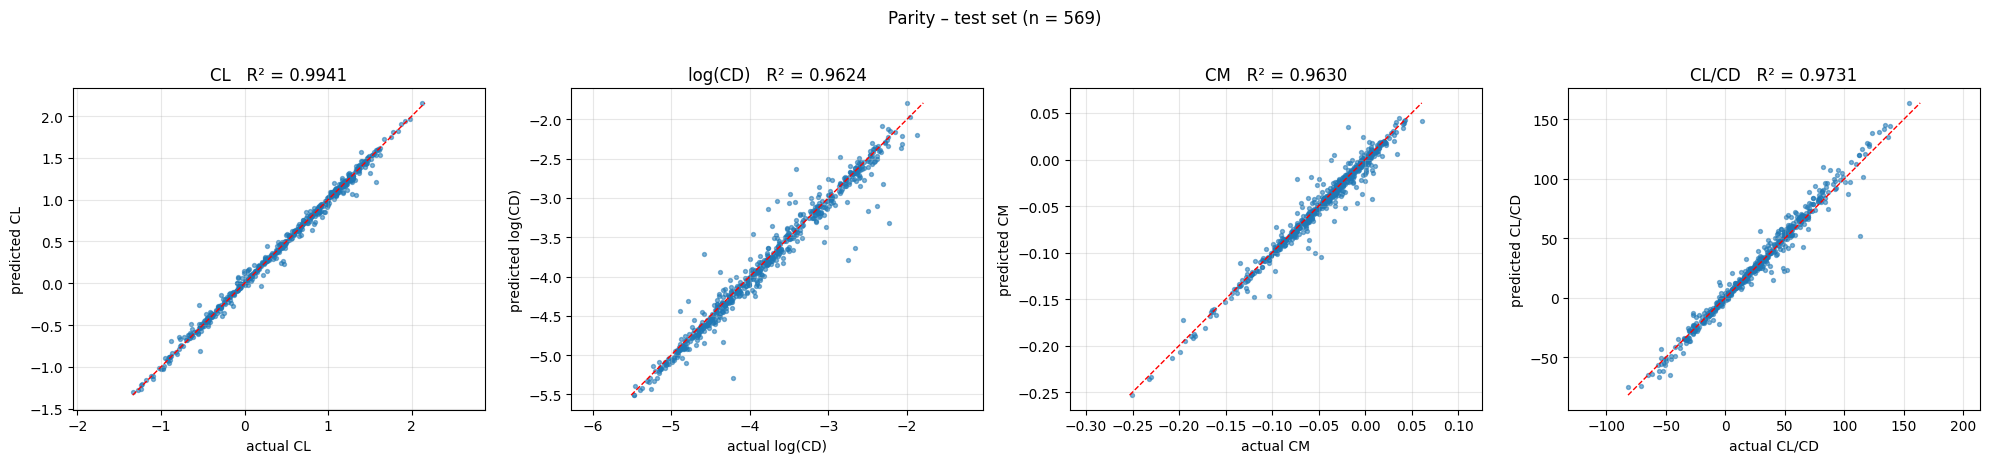

In [2]:
metrics = evaluate(plot=True, show=True, save_path="model_parity.png")

## 1. Build the problem

`build_problem` loads the trained `airfoil_surrogate.pt`, constructs the 12-D geometry-only design space, applies physical lower/upper bounds, and pre-builds the constraint lists (one for SLSQP, one for COBYQA / trust-constr). Tweak the kwargs below to change the problem.

In [3]:
prob = build_problem(
    thickness_reduction = 0.10,   # 10 % thinner than kc135 at every sampled station
    cl_min              = 0.10,   # CL must stay ≥ this
    bounds_slack        = 0.02,   # widen training-data bounds by 2 % of span
    enable_coherence    = True,   # add the 5 linear coherence inequalities
)

cl_b, cd_b, cm_b = prob["kc135_pred"]
print(f"kc135 baseline   : CL={cl_b:.4f}  CD={cd_b:.6f}  CL/CD={cl_b/cd_b:.3f}  CM={cm_b:.4f}")
print(f"thickness target : {prob['thk_targets']}")
print(f"CL minimum       : {prob['cl_min']}")
print(f"design dim       : {len(prob['u0'])} (geometry-only, in u-space [0,1])")
print(f"coherence rules  :")
for c in COHERENCE_LABELS:
    print(f"  - {c}")

kc135 baseline   : CL=1.1630  CD=0.014456  CL/CD=80.449  CM=-0.0064
thickness target : [0.1224 0.1381 0.1034 0.0518]
CL minimum       : 0.1
design dim       : 12 (geometry-only, in u-space [0,1])
coherence rules  :
  - max_camber ≥ camber_x_0.25_y
  - max_camber ≥ camber_x_0.5_y
  - max_camber ≥ camber_x_0.75_y
  - thickness_x_0.4_y ≥ thickness_x_0.6_y
  - thickness_x_0.6_y ≥ thickness_x_0.8_y


## 2. Run all three optimisers

Each `run_*` returns `(scipy_result, TrackingProblem)`. The tracker has logged the objective and the max-constraint-violation **at every function evaluation** scipy made — that's what the convergence plots in the next cells use.

In [4]:
print("running SLSQP …");        res_s, tr_s = run_slsqp(prob)
print("running COBYQA …");       res_c, tr_c = run_cobyqa(prob)
print("running trust-constr …"); res_t, tr_t = run_trust_constr(prob)

results  = {"SLSQP": (res_s, tr_s),
            "COBYQA": (res_c, tr_c),
            "trust-constr": (res_t, tr_t)}
trackers = {name: tr for name, (_, tr) in results.items()}

for name, (res, tr) in results.items():
    print(f"  {name:<14s}  success={bool(res.success)}  "
          f"CL/CD={-res.fun:.3f}  evaluations={len(tr.f_calls)}")

running SLSQP …


running COBYQA …


running trust-constr …


  SLSQP           success=True  CL/CD=164.017  evaluations=1097
  COBYQA          success=True  CL/CD=107.114  evaluations=498
  trust-constr    success=True  CL/CD=131.874  evaluations=394


## 3. Objective history — CL/CD at every function evaluation

x-axis = the k-th call scipy made to the objective. y-axis = CL/CD predicted by the surrogate at that point. Dashed line = kc135 baseline.

  saved → objective_history.png


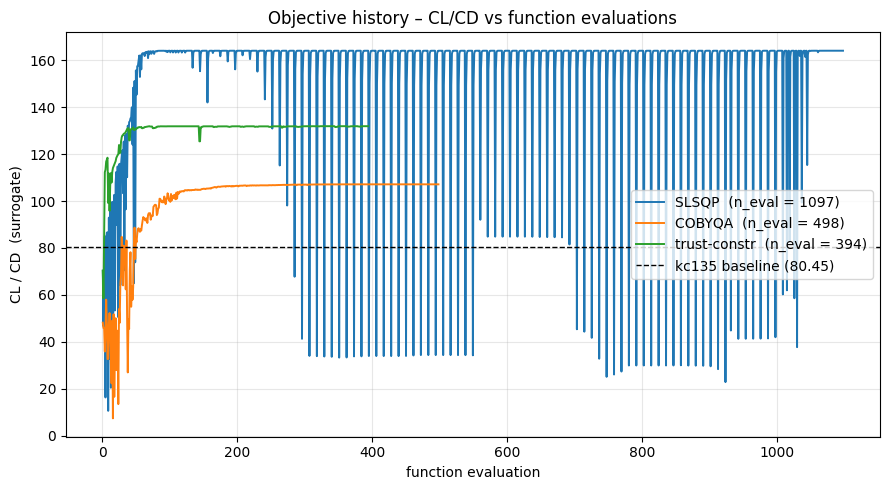

In [5]:
_ = plot_objective_history(trackers, baseline_clcd=cl_b/cd_b,
                           save_path="objective_history.png")

## 4. Constraint violation history

For every function evaluation, the maximum violation over **all** inequality constraints (CL minimum, thickness profile, coherence, bounds) is recorded:

$$\text{violation}(u_k) \;=\; \max_i \, \max\bigl(0,\, -g_i(u_k)\bigr)$$

Plotted on a log scale. The dotted reference line is at 1e-6 — anything below counts as practically feasible.

  saved → violation_history.png


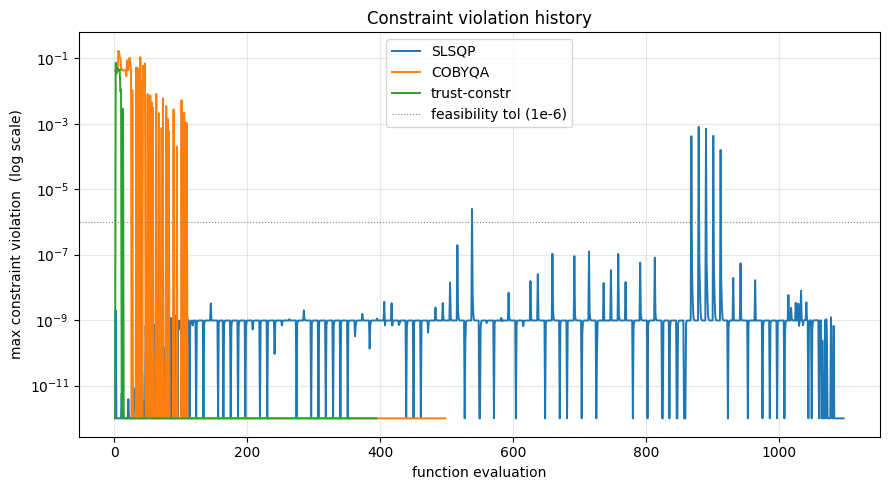

In [6]:
_ = plot_violation_history(trackers, save_path="violation_history.png")

## 5. Summary table

In [7]:
summary_table(prob, results)

  method          success      CL/CD        CL         CD   peak_thk      LE_r   evals
  kc135 baseline        -     80.449    1.1630   0.014456   0.153452    0.0205       -
  SLSQP              True    164.017    1.9114   0.011654   0.122410    0.0001    1097
  COBYQA             True    107.114    1.1916   0.011125   0.126288    0.0001     498
  trust-constr       True    131.874    1.5078   0.011434   0.119948    0.0101     394


## 6. Save the optimised geometries

In [8]:
saved = save_results(prob, results, out_dir=".")

  saved → .\slsqp_result.npy
  saved → .\cobyqa_result.npy
  saved → .\trust_constr_result.npy


## 7. Reconstruct and plot the airfoil shapes

Top panel: upper + lower surfaces (PCHIP through the 4 thickness samples and 3 camber samples; closed at LE and TE; cosine x-spacing). Open circles = thickness samples for the kc135 baseline; open squares = camber samples. Dashed = mean camber line.

Bottom panel: full thickness profile of every airfoil overlaid for direct comparison.

Saved → airfoil_shapes.png


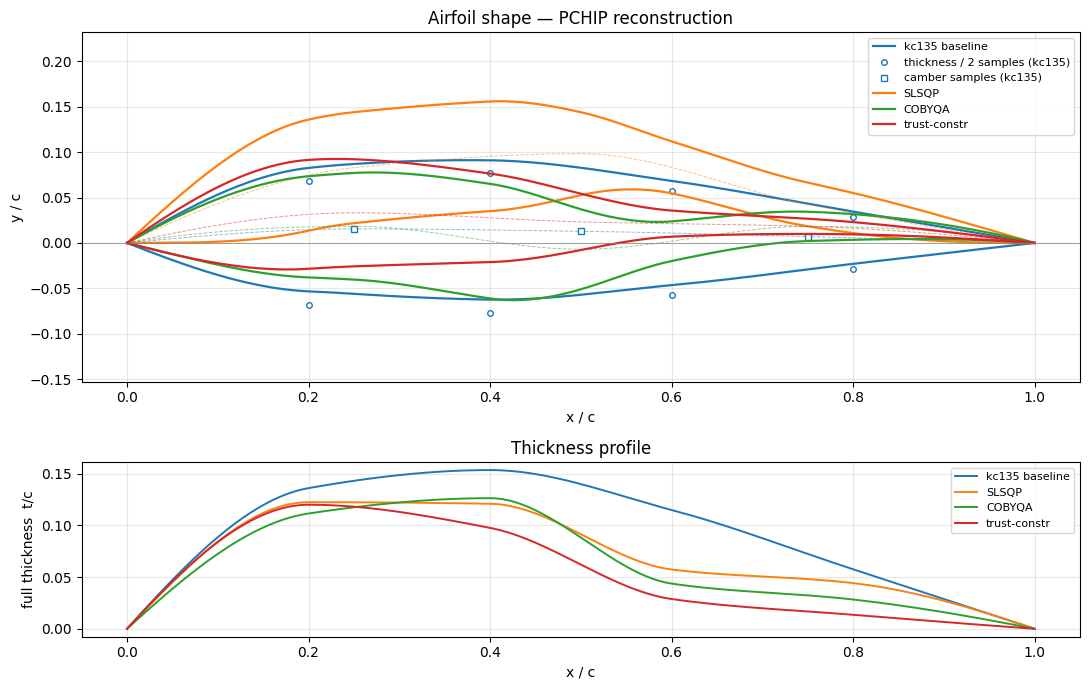

In [9]:
geoms = {"kc135 baseline": KC135_GEOM, **saved}
_ = plot_airfoils(geoms, save_path="airfoil_shapes.png")

## 8. Per-solver detailed report

Calls `report_result` from `airfoil_opt_utils.py` for each solver — feature-by-feature delta vs kc135, plus per-constraint OK / VIOLATED status.

In [10]:
from airfoil_opt_utils import report_result
for name, (res, tr) in results.items():
    report_result(name, res, prob)


══════════════════════════════════════════════════════════════════════════════
  SLSQP result
══════════════════════════════════════════════════════════════════════════════
  success        : True
  message        : Optimization terminated successfully
  nfev / nit     : 1097 / 162
  −CL/CD (obj)   : -164.016872
   CL/CD         : +164.016872    (baseline kc135: +80.449)
   CL            : +1.911402    (baseline +1.1630)
   CD            : +0.01165368    (baseline +0.014456)
   CM            : -0.160294    (baseline -0.0064)
   CL ≥ 0.100     : OK

  Coherence constraints (g(u) ≥ 0):
    max_camber ≥ camber_x_0.25_y                g = +0.015406   OK
    max_camber ≥ camber_x_0.5_y                 g = +0.000000   OK
    max_camber ≥ camber_x_0.75_y                g = +0.055916   OK
    thickness_x_0.4_y ≥ thickness_x_0.6_y       g = +0.063570   OK
    thickness_x_0.6_y ≥ thickness_x_0.8_y       g = +0.013131   OK

  Thickness profile (target = 0.9 × kc135):
    station                 